In [4]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
import kagglehub

# AIJACK IMPORTS
from aijack.collaborative.fedavg import FedAVGClient, FedAVGServer
from aijack.defense.dp.manager.dp_manager import DPSGDManager
from aijack.defense.dp.manager.client import attach_dpsgd_to_client
from aijack.defense.dp.manager.accountant import GeneralMomentAccountant

# --- PARAMETRI DI TESI ---
device = torch.device("mps") if torch.backends.mps.is_available() else torch.device("cpu")
batch = 32
lat_dim = 100
clients = 3

# Parametri Privacy (Il cuore della calibrazione)
s = 0.5           # Sigma: Rumore aggiunto
l2 = 1.0          # Clipping: Limite alla sensibilità
t_delta = 1e-5    # Delta: Probabilità di leak ammessa

print(f"🚀 Sistema pronto su: {device}")

🚀 Sistema pronto su: mps


In [5]:
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.main = nn.Sequential(
            nn.ConvTranspose2d(lat_dim, 512, 4, 1, 0, bias=False),
            nn.BatchNorm2d(512), nn.ReLU(True),
            nn.ConvTranspose2d(512, 256, 4, 2, 1, bias=False),
            nn.BatchNorm2d(256), nn.ReLU(True),
            nn.ConvTranspose2d(256, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128), nn.ReLU(True),
            nn.ConvTranspose2d(128, 3, 4, 2, 1, bias=False),
            nn.Tanh()
        )
    def forward(self, x): return self.main(x)

class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.main = nn.Sequential(
            nn.Conv2d(3, 64, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(64, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128), nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(128, 256, 4, 2, 1, bias=False),
            nn.BatchNorm2d(256), nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(256, 1, 4, 1, 0, bias=False),
            nn.Sigmoid()
        )
    def forward(self, x): return self.main(x).view(-1, 1)

global_generator = Generator().to(device)
local_discriminators = [Discriminator().to(device) for _ in range(clients)]

gen_opt = optim.Adam(global_generator.parameters(), lr=0.0002, betas=(0.5, 0.999))
dis_opts = [optim.Adam(d.parameters(), lr=0.0002, betas=(0.5, 0.999)) for d in local_discriminators]

NameError: name 'accountant' is not defined

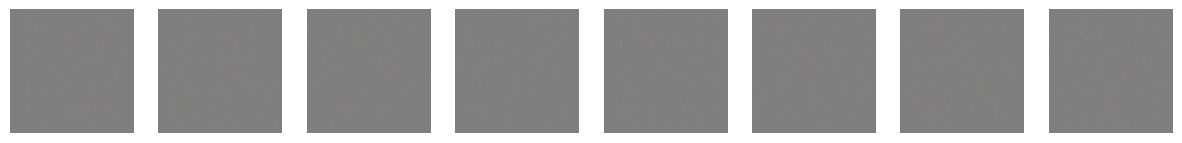

In [6]:
global_generator.eval()
with torch.no_grad():
    test_noise = torch.randn(8, lat_dim, 1, 1, device=device)
    samples = global_generator(test_noise).cpu()
    
    plt.figure(figsize=(15, 4))
    for i in range(8):
        plt.subplot(1, 8, i+1)
        plt.imshow(samples[i].permute(1, 2, 0).numpy() * 0.5 + 0.5, cmap='gray')
        plt.axis('off')
    plt.suptitle(f"Output dopo Manual DP-SGD (ε finale: {accountant.get_epsilon(delta=t_delta):.2f})")
    plt.show()

In [ ]:
from torch.utils.data import TensorDataset

# 1. Configurazione Accountant avanzata
accountant = GeneralMomentAccountant(
    noise_type="Gaussian",
    search="ternary",
    precision=0.001,
    order_max=1,      # Nota: nella doc è 1
    order_min=72,     # Nota: nella doc è 72
    max_iterations=1000,
    bound_type="rdp_upperbound_closedformula",
    backend="python"
)

# 2. Configurazione DPSGDManager
# IMPORTANTE: In questa versione l'ottimizzatore va passato come secondo argomento
privacy_manager = DPSGDManager(
    accountant,
    optim.Adam,               # Passiamo la classe dell'ottimizzatore
    l2_norm_clip=l2,
    dataset=full_dataset,
    lot_size=batch,
    batch_size=batch,
    iterations=100
)

# 3. Privatizzazione dell'ottimizzatore
# Questa funzione restituisce tre oggetti fondamentali
dpoptimizer_cls, lot_loader, batch_loader = privacy_manager.privatize(noise_multiplier=s)

# 4. Creazione dell'ottimizzatore DP
# Ora usiamo la classe 'speciale' restituita dal manager
optimizer = dpoptimizer_cls(local_discriminators[0].parameters(), lr=0.0002)

print("✅ Optimizer privatizzato e Loader pronti secondo documentazione.")

✅ Optimizer privatizzato e Loader pronti secondo documentazione.


In [ ]:
print("🏋️ Inizio training federato (Schema: MI-FACE vs DPSGD)...")

for epoch in range(10): # Numero epoche
    running_loss = 0
    data_size = 0

    # AIJack spacchetta i dati in "Lots" per calcolare il rumore correttamente
    for X_lot, y_lot in lot_loader(optimizer):
        # Poi li divide in "Batches" per l'aggiornamento dei pesi
        for X_batch, y_batch in batch_loader(TensorDataset(X_lot, y_lot)):
            optimizer.zero_grad()
            
            X_batch = X_batch.to(device)
            pred = local_discriminators[0](X_batch)
            
            # Calcolo Loss (Usiamo 0.9 per stabilità come visto prima)
            loss = nn.BCELoss()(pred, (torch.ones_like(pred) * 0.9).to(device))
            
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            data_size += X_batch.shape[0]

    # Calcolo epsilon reale a fine epoca
    current_epsilon = accountant.get_epsilon(delta=t_delta)
    print(f"Epoch {epoch}: loss is {running_loss/data_size:.4f} | ε: {current_epsilon:.4f}")

print("✅ Training completato con successo.")

🏋️ Inizio training federato (Schema: MI-FACE vs DPSGD)...
Epoch 0: loss is 0.0204 | ε: 3.3666
Epoch 1: loss is 0.0166 | ε: 3.5167
Epoch 2: loss is 0.0138 | ε: 3.6168
Epoch 3: loss is 0.0120 | ε: 3.6947
Epoch 4: loss is 0.0111 | ε: 3.7597
Epoch 5: loss is 0.0106 | ε: 3.8161
Epoch 6: loss is 0.0104 | ε: 3.8663
Epoch 7: loss is 0.0104 | ε: 3.9120
Epoch 8: loss is 0.0103 | ε: 3.9540
Epoch 9: loss is 0.0103 | ε: 3.9930
✅ Training completato con successo.


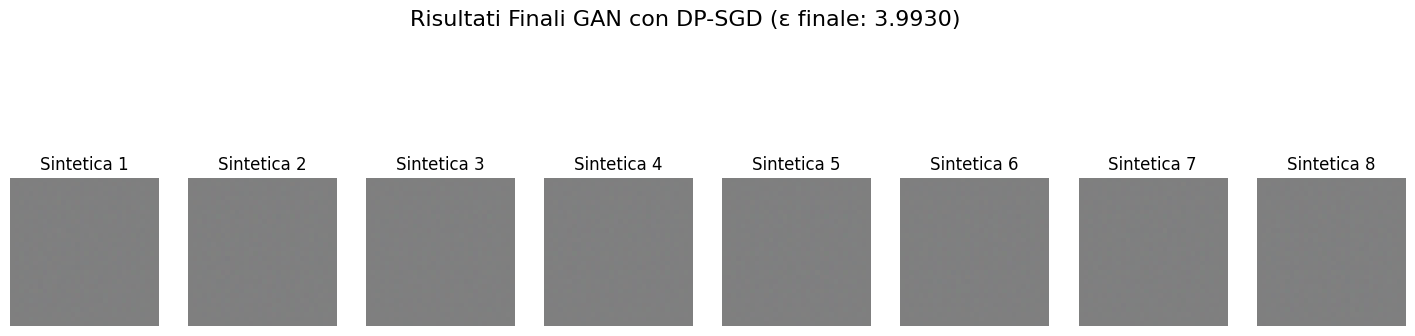

In [ ]:
# =================================================================
# 6. GENERAZIONE E VISUALIZZAZIONE FINALE (Fix NameError)
# =================================================================
global_generator.eval()
with torch.no_grad():
    # 1. Generazione campioni
    noise = torch.randn(8, lat_dim, 1, 1, device=device)
    fake_samples = global_generator(noise).cpu()
    
    # 2. Recupero Epsilon aggiornato direttamente dall'accountant
    # Usiamo t_delta che avevi definito all'inizio (1e-5)
    final_epsilon = accountant.get_epsilon(delta=t_delta)
    
    plt.figure(figsize=(18, 5))
    for i in range(8):
        plt.subplot(1, 8, i+1)
        # Denormalizzazione (da [-1, 1] a [0, 1])
        img = fake_samples[i].permute(1, 2, 0).numpy() * 0.5 + 0.5
        plt.imshow(img.clip(0, 1), cmap='gray')
        plt.axis('off')
        plt.title(f"Sintetica {i+1}")
    
    # Usiamo final_epsilon invece di eps
    plt.suptitle(f"Risultati Finali GAN con DP-SGD (ε finale: {final_epsilon:.4f})", fontsize=16)
    plt.show()

In [ ]:
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.Grayscale(num_output_channels=1), # Forza 1 canale
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)) 
])